# Exercise

In this exercise, you will write our own Metropolis-Hastings MCMC code and apply it to a simple two-dimensional problem. The prior and likelihood are defined below. For visualization purposes, we will explore a simple two-dimensional problem. We assume flat priors on each parameter in the range $[-10, +10]$ and the likelihood has the shape of a [Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function). I'm also providing you with a minimal MCMC sampler class. **However, you need to implement the sampling step yourself.**

In this exercise, you will explore how the chain behaves, assess convergence, and examine how the proposal scale influences performance.

(a) Implement the sampling step and run the sampler for $100$ iterations with the default proposal scale. You should see the sampler move inside the high-likelihood region. If the sampler doesn't move (acceptance rate of 0%) or moves away from the high-likelihood region, check your code again.

(b) Make trace plots for both parameters. Identify how many iterations are roughly needed to achieve a converged result. Remember that for a converged result, the chains should explore the range of each parameters several times.

(c) Make one-dimensional histograms of each of the two parameters in the chain. What is the posterior mean and standard deviation of the two parameters?

(d) Change the proposal scale. How does the proposal scale affect the acceptance rate and convergence of the MCMC chain?

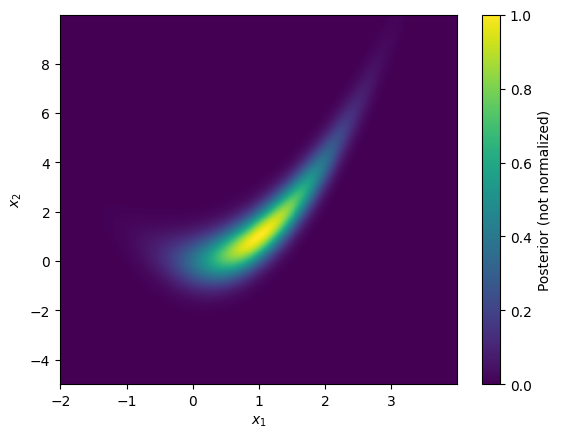

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def log_prior(x):
    """Compute the logarithm of the prior.

    The prior is a flat prior in the range [-10, +10] for all parameters.

    Parameters
    ----------
    x : numpy.ndarray of shape (n_points, n_dim) or (n_dim, )
        Point(s) in parameter space.

    Returns
    -------
    float or numpy.ndarray
        Natural logarithm of the prior for the input parameter(s).

    """
    return np.where(np.any(np.abs(x) > 10, axis=-1), -np.inf, 0)

def log_likelihood(x):
    """Compute the logarithm of the likelihood.

    Parameters
    ----------
    x : numpy.ndarray of shape (n_points, 2) or (2, )
        Point(s) in parameter space.

    Returns
    -------
    float or numpy.ndarray
        Natural logarithm of the likelihood for the input parameter(s).

    """
    return -((1 - x[..., 0])**2 + (x[..., 1] - x[..., 0]**2)**2)

def log_posterior(x):
    """Compute the logarithm of the posterior.

    Parameters
    ----------
    x : numpy.ndarray of shape (n_points, 2) or (2, )
        Point(s) in parameter space.

    Returns
    -------
    float or numpy.ndarray
        Natural logarithm of the posterior for the input parameter(s).

    """
    return log_prior(x) + log_likelihood(x)

# Do not modify. This is just to visualize the posterior.
x1, x2 = np.mgrid[-2:4:0.01, -5:10:0.01]
x = np.column_stack([x1.ravel(), x2.ravel()])
plt.pcolormesh(x1, x2, np.exp(log_posterior(x).reshape(x1.shape)))
plt.colorbar(label='Posterior (not normalized)')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$');

In [67]:
def run_mcmc(start, posterior, n_iter, scale=1.0, burn_in=0):
    """Run an MCMC chain.

    Attributes
    ----------
    start : numpy.ndarray of shape (n_dim, )
        Starting position.
    posterior : callable
        Function that returns the logarithm of the posterior.
    n_iter : int
        Number of iterations.
    scale : float, optional
        Proposal scale. Default is 1.
    burn_in : int, optional
        Number of samples to remove as burn-in.

    Returns
    -------
    chain : numpy.ndarray of shape (n_samples, n_dim)
            Posterior chain.
    f_accept : float
            Acceptance fraction.
    """
    x = start.copy()
    log_p = posterior(x)
    chain = np.zeros((n_iter + 1, len(x)))
    chain[0] = x

    for i in range(1, n_iter + 1):

        # Draw a random step
        step = np.random.normal(scale=scale, size=len(x))

        # Calculate the new proposed position.
        x_new = x + step

        # Your code to decide whether to accept x_new goes here.
        p_x = np.exp(log_posterior(x))
        p_x_prime = np.exp(log_posterior(x_new))
        acceptance_prob = p_x_prime / p_x
        x = min(acceptance_prob, 1)

        # Add the current position to the chain.
        chain[i] = x

    return chain, np.mean(chain[1:] != chain[:-1])

In [68]:
chain, f_accept = run_mcmc(np.zeros(2), log_posterior, 100)

x1, x2 = np.mgrid[-2:4:0.01, -5:10:0.01]
x = np.column_stack([x1.ravel(), x2.ravel()])
plt.pcolormesh(x1, x2, np.exp(log_posterior(x).reshape(x1.shape)), zorder=0,
              cmap='Greys')
plt.scatter(chain[:, 0], chain[:, 1], lw=0, c=np.arange(len(chain)) + 1,
            s=3, zorder=2);
plt.plot(chain[:, 0], chain[:, 1], color='red', lw=0.5, zorder=1)
plt.colorbar(label='MCMC Iteration')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')

print(f'Acceptance Fraction: {f_accept:.0%}')

TypeError: object of type 'int' has no len()